In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import pandas as pd
import numpy as np
from yllib.function import myfunc
from yllib.plot import plot_map
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
%config InlineBackend.figure_format='retina'

In [2]:
version = 'results_v3.1'
seasons = ['ANN', 'MAM', 'JJA', 'SON', 'DJF']

## Plot figures

In [3]:
def plot_on_map(data, u=None, v=None, **kwargs):
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['font.family'] = 'Helvetica'  
    
    # create a figure
    if (fig:=kwargs.get('fig')) is None:  
        fig = plt.figure(figsize=(8, 5))
    if (ax:=kwargs.get('ax')) is None:  ax = plt.axes()
    ax.set_axis_on()
    
    # set map - extent, grid, coastline ...
    plot_map.set_map(
        ax,
        extent=kwargs.get('extent',[-125+360,-70+360,24,50]),
        # extent=[0,360,15,90],
        gridlines_kw=dict(
            xticks=[-130,-125,-120],
            yticks=[30,35,40,45],
            linestyle=":", alpha=0.3,
        ),
        gridlabels_kw=dict(
            xticks=[-130,-125,-120] if kwargs.get('drawxticks', False) else [],
            yticks=[30,35,40,45] if kwargs.get('drawyticks', False) else [],
        ),
        boundary_kw=dict(
            draw_state=True,
            coastline_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
            draw_borders=True,
            border_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
        ),
    )
    
    # lat and lon for contour plot
    if ((lon:=kwargs.get('lon')) is None): lon = data['lon']
    if ((lat:=kwargs.get('lat')) is None): lat = data['lat']
        
    # draw contourf
    cmap = kwargs.get('cmap', "WhiteBlueGreenYellowRed")
    clev = kwargs.get('clev', np.arange(0, 40, 1))
    # cs, clev = plot_map.add_contourf(
    cs, clev = plot_map.add_pcolormesh(
        ax, lon, lat, data,
        # cmap=cm_wind['cmap'],clev=clev,
        cmap=cmap,clev=clev,
    )
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.25,0.5,0.75,1], colors='k', zorder=10)        
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.1,0.2,0.3,0.4,0.5,0.75,1], colors='k', zorder=10)        
    
    # cs = ax.contourf(lon, lat, data, cmap=cm_wind['cmap'], norm=cm_wind['norm'], clev=clev)
    if (u is not None) & (v is not None):
        d = 20
        _lat = lat[::d,::d]
        _lon = lon[::d,::d]
        # uu, vv = rotate_wind(u[::d,::d], v[::d,::d], _lon)
        uu, vv = u[::d,::d], v[::d,::d]
        vec = plot_map.add_vector(ax,
            _lon, _lat, uu, vv,
            vector_kwargs=dict(
                scale_units="inches", scale=kwargs.get('vector_scale',30),
            )
        )
        rect = mpl.patches.Rectangle(
            (0., 0),  # (x, y)
            0.25,  # width
            0.1,  # height
            facecolor='white',
            edgecolor='gray',
            transform=ax.transAxes,
        )
        ax.add_patch(rect)
        ax.quiverkey(vec, 0.10, 0.05, 5, "5",labelpos='E', coordinates='axes')
    
    if (overlay:=kwargs.get('overlay')) is not None:
        plot_map.add_hatches(ax, lon, lat, overlay, clev=[0, 0.05], zorder=10)

        
    # add text - title, ananote
    if (title:=kwargs.get('title')) is not None: 
        default_title_kwargs = dict(loc='left')
        default_title_kwargs.update(kwargs.get('title_kwargs', {}))
        ax.set_title(title, **default_title_kwargs)

    if kwargs.get('draw_colorbar'):
        plot_map.add_colorbar(cs, ax, clev[1:-1])
        
    return cs, clev

In [4]:
mask = xr.open_dataarray('mask_4D.nc').isel(hour=0, channel=0)
def load_statistics(expr, seasons):
    stats = {}
    for season in seasons:
        statisfile = f"statistics/accuracy.{expr}.{season}.nc"
        stats[season] = xr.open_dataarray(statisfile).where(mask)
    return xr.Dataset(stats)

In [5]:
accuracy_lisa = load_statistics('lisa3.1', seasons)
accuracy_lisa_4hr = load_statistics('lisa3.1_4hr', seasons)
accuracy_unet = load_statistics('unet', seasons)

In [6]:
lat = np.load(f'hrrr_lat.npy')
lon = np.load(f'hrrr_lon.npy')

(1.0, 0.0)
(1.0, 0.0)


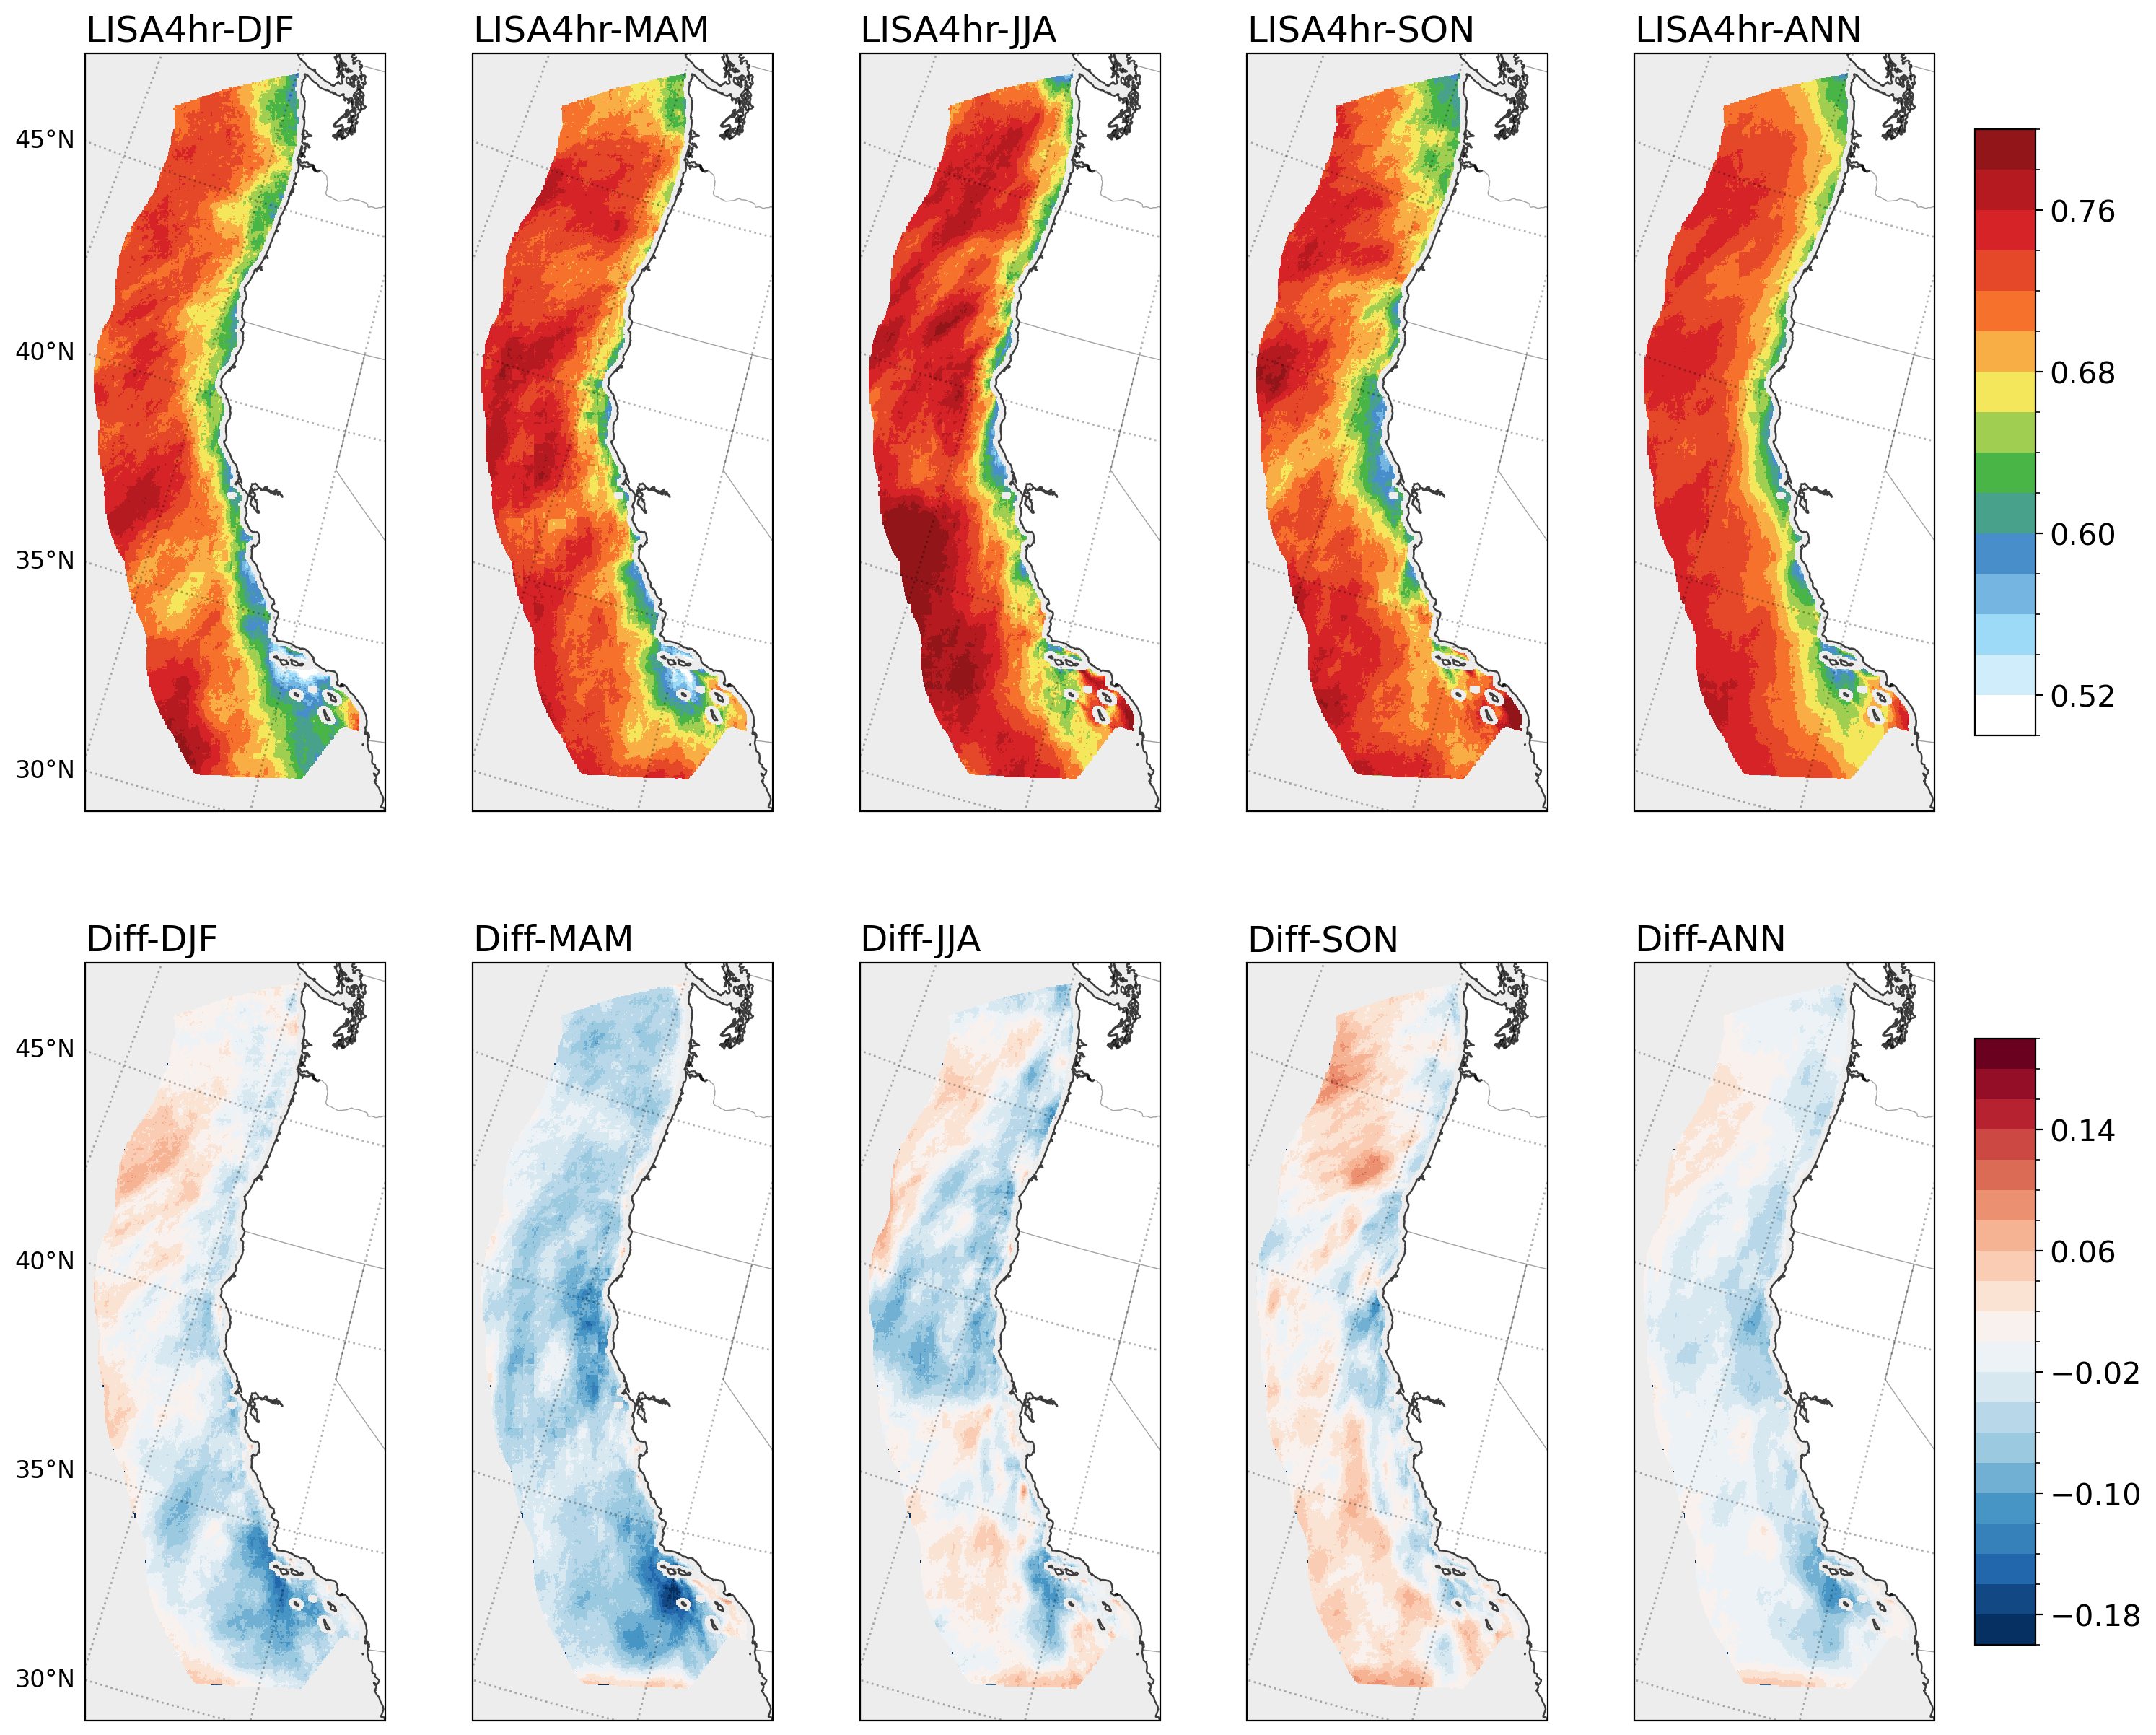

In [13]:
map_extent = [235.2, 238.2, 29.721663, 48.909824]
projection = ccrs.LambertConformal(central_longitude=-97.7,)
fig, axs = plt.subplots(
    2, 5, figsize=(18, 15), 
    subplot_kw={'projection': projection},
)
axs = axs.ravel()

disp_dict = dict(
    LISA_DJF={'data':accuracy_lisa_4hr['DJF'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA4hr-DJF'},
    Diff_DJF={'data':accuracy_lisa_4hr['DJF'] - accuracy_unet['DJF'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-DJF'},
    LISA_MAM={'data':accuracy_lisa_4hr['MAM'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA4hr-MAM'},
    Diff_MAM={'data':accuracy_lisa_4hr['MAM'] - accuracy_unet['MAM'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-MAM'},    
    LISA_JJA={'data':accuracy_lisa_4hr['JJA'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA4hr-JJA'},
    Diff_JJA={'data':accuracy_lisa_4hr['JJA'] - accuracy_unet['JJA'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-JJA'},
    LISA_SON={'data':accuracy_lisa_4hr['SON'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA4hr-SON'},
    Diff_SON={'data':accuracy_lisa_4hr['SON'] - accuracy_unet['SON'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-SON'},
    LISA_ANN={'data':accuracy_lisa_4hr['ANN'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA4hr-ANN'},
    Diff_ANN={'data':accuracy_lisa_4hr['ANN'] - accuracy_unet['ANN'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-ANN'},
)

for i, (key, value) in enumerate(disp_dict.items()):
    row = i % 2  # Row position (0, 1, 2, 0, 1, 2, ...)
    col = i // 2  # Column position (0, 0, 0, 1, 1, 1, ...)
    ii = row * 5 + col  # Convert to flattened index
    data = value['data']
    cs, clev = plot_on_map(
        data,
        fig=fig, ax=axs[ii], extent=map_extent,
        clev=value['clev'],
        draw_colorbar=False,
        lat=lat, lon=lon,
        cmap=value['cmap'],
        title=value['title'],
        drawxticks=False if ii < 5 else True,
        drawyticks=True if ii % 5 == 0 else False,
    # cmap='WhiteGreen',
    # title=f'({abcd[2]}) {expr[2]}',
    # title_kwargs=dict(fontsize=16),
    ) 
    if ii<5: cs1 = cs; clev1 = clev
    if ii>5: cs2 = cs; clev2 = clev
_=plot_map.add_colorbar(cs1, axs[:5], clev1[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')
_=plot_map.add_colorbar(cs2, axs[5:], clev2[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')


plt.savefig('figure_comparison_lisa4h_unet_accuracy.png', dpi=300, bbox_inches='tight')


(1.0, 0.0)
(1.0, 0.0)


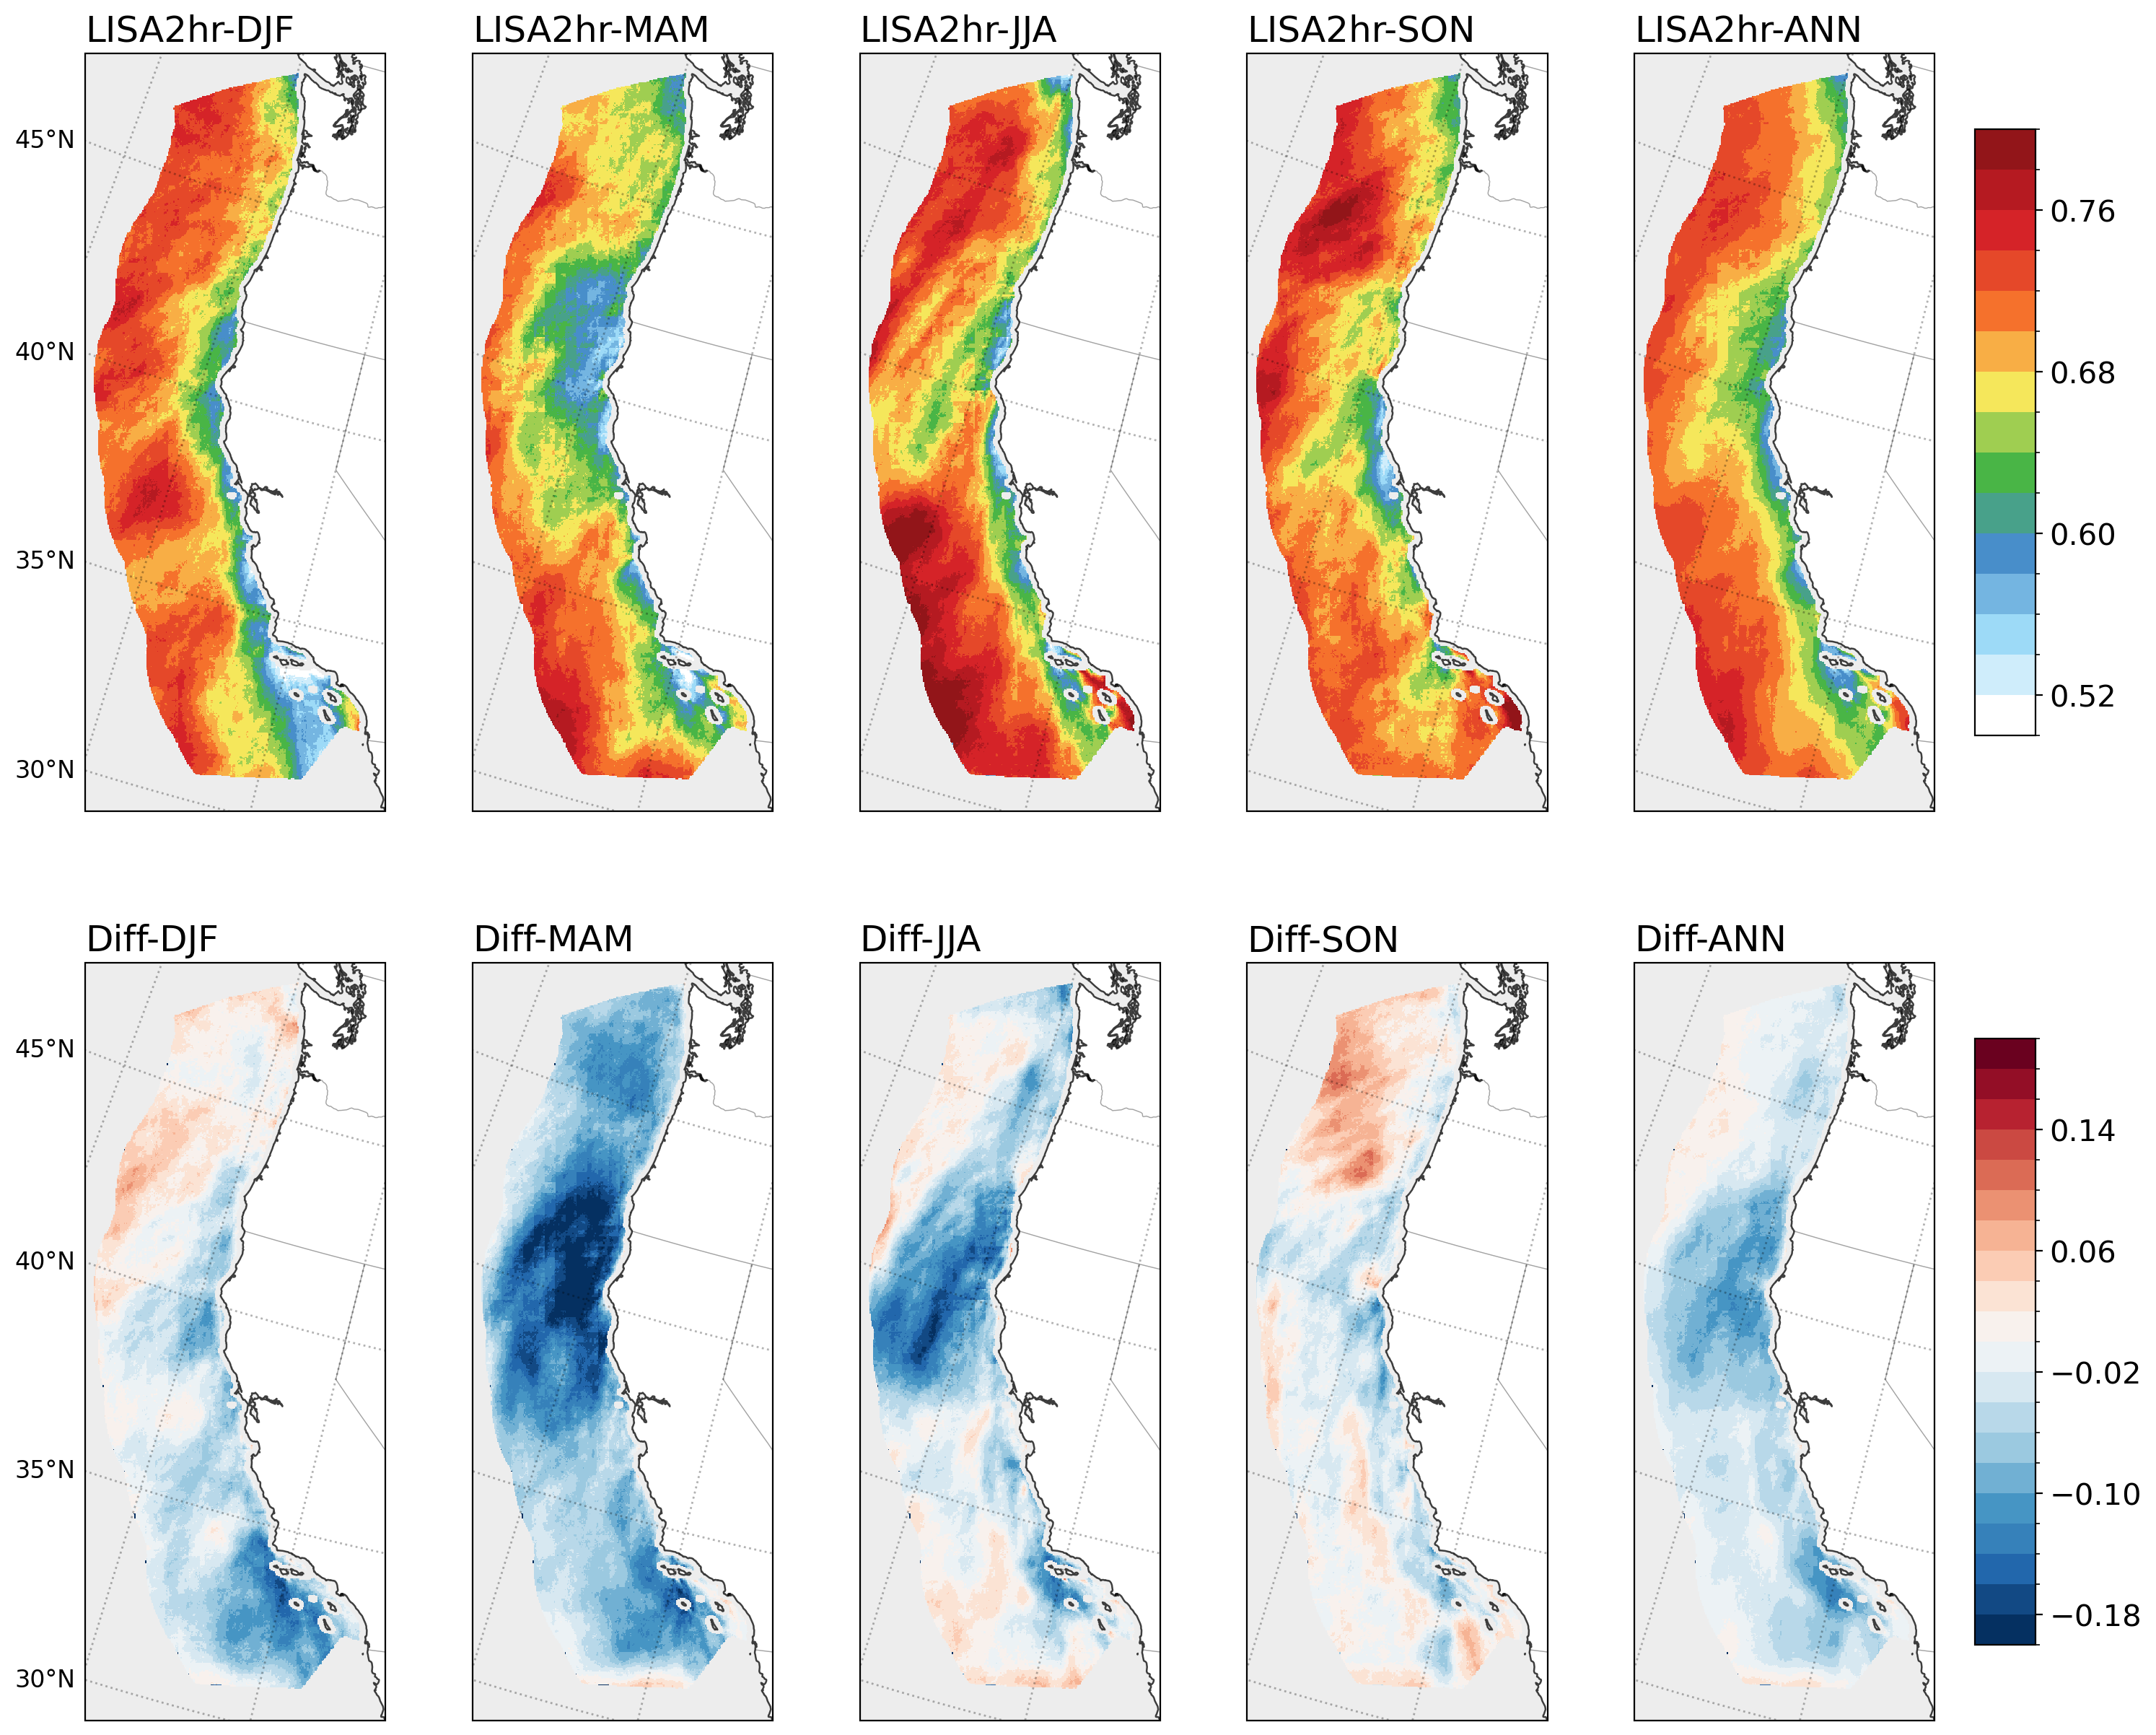

In [18]:
map_extent = [235.2, 238.2, 29.721663, 48.909824]
projection = ccrs.LambertConformal(central_longitude=-97.7,)
fig, axs = plt.subplots(
    2, 5, figsize=(18, 15), 
    subplot_kw={'projection': projection},
)
axs = axs.ravel()

disp_dict = dict(
    LISA_DJF={'data':accuracy_lisa['DJF'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA2hr-DJF'},
    Diff_DJF={'data':accuracy_lisa['DJF'] - accuracy_unet['DJF'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-DJF'},
    LISA_MAM={'data':accuracy_lisa['MAM'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA2hr-MAM'},
    Diff_MAM={'data':accuracy_lisa['MAM'] - accuracy_unet['MAM'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-MAM'},    
    LISA_JJA={'data':accuracy_lisa['JJA'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA2hr-JJA'},
    Diff_JJA={'data':accuracy_lisa['JJA'] - accuracy_unet['JJA'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-JJA'},
    LISA_SON={'data':accuracy_lisa['SON'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA2hr-SON'},
    Diff_SON={'data':accuracy_lisa['SON'] - accuracy_unet['SON'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-SON'},
    LISA_ANN={'data':accuracy_lisa['ANN'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'LISA2hr-ANN'},
    Diff_ANN={'data':accuracy_lisa['ANN'] - accuracy_unet['ANN'], 'cmap':'MPL_RdBu_r', 'clev':np.linspace(-0.2,0.2,21), 'title':'Diff-ANN'},
)

for i, (key, value) in enumerate(disp_dict.items()):
    row = i % 2  # Row position (0, 1, 2, 0, 1, 2, ...)
    col = i // 2  # Column position (0, 0, 0, 1, 1, 1, ...)
    ii = row * 5 + col  # Convert to flattened index
    data = value['data']
    cs, clev = plot_on_map(
        data,
        fig=fig, ax=axs[ii], extent=map_extent,
        clev=value['clev'],
        draw_colorbar=False,
        lat=lat, lon=lon,
        cmap=value['cmap'],
        title=value['title'],
        drawxticks=False if ii < 5 else True,
        drawyticks=True if ii % 5 == 0 else False,
    # cmap='WhiteGreen',
    # title=f'({abcd[2]}) {expr[2]}',
    # title_kwargs=dict(fontsize=16),
    ) 
    if ii<5: cs1 = cs; clev1 = clev
    if ii>5: cs2 = cs; clev2 = clev
_=plot_map.add_colorbar(cs1, axs[:5], clev1[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')
_=plot_map.add_colorbar(cs2, axs[5:], clev2[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')

plt.savefig('figure_comparison_lisa2h_unet_accuracy.png', dpi=300, bbox_inches='tight')


(1.0, 0.0)


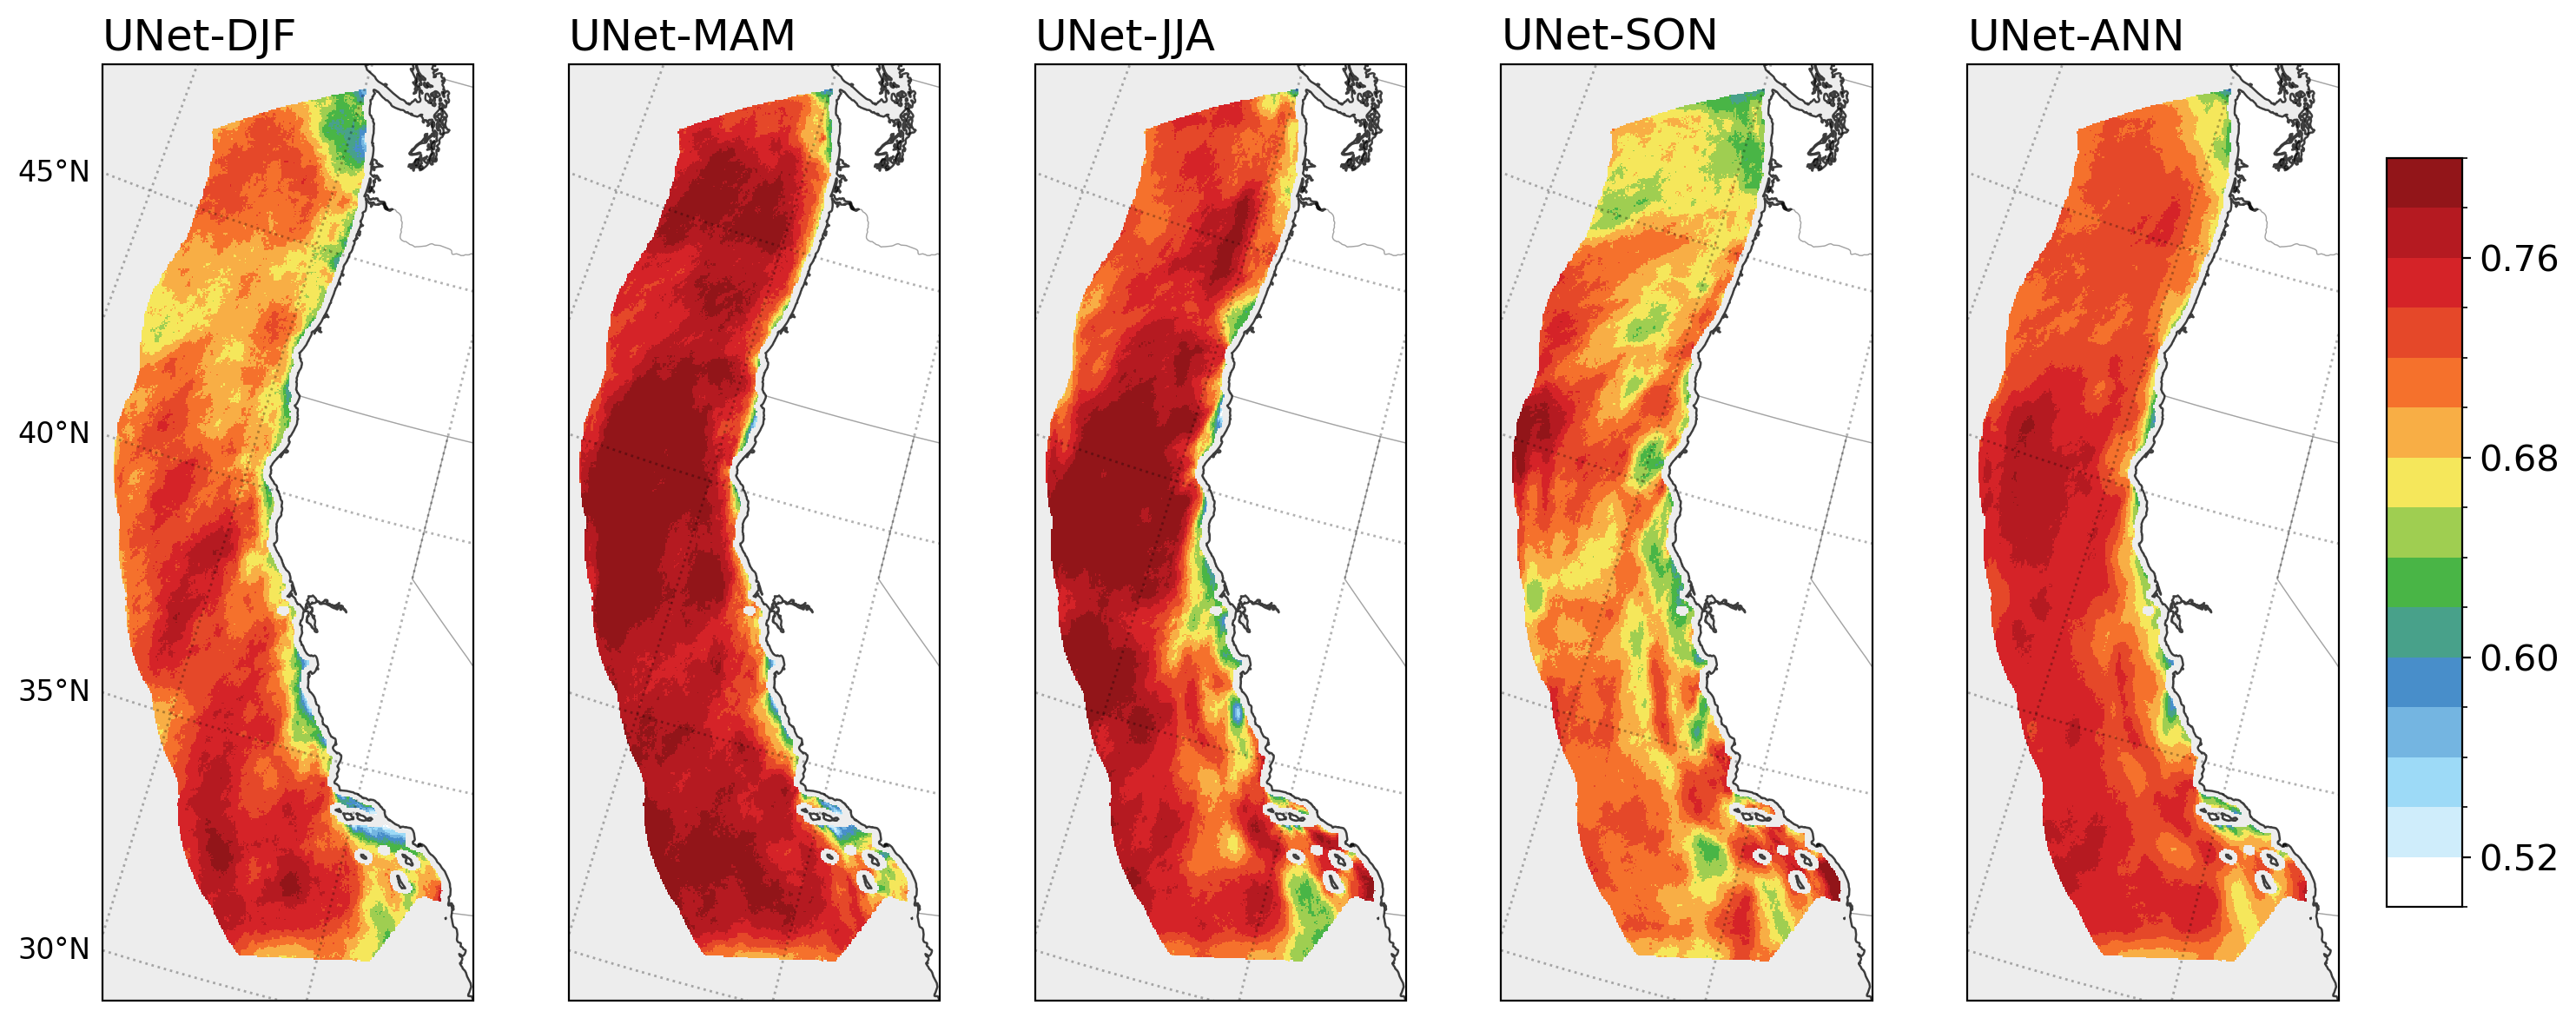

In [19]:
map_extent = [235.2, 238.2, 29.721663, 48.909824]
projection = ccrs.LambertConformal(central_longitude=-97.7,)
fig, axs = plt.subplots(
    1, 5, figsize=(18, 7), 
    subplot_kw={'projection': projection},
)
axs = axs.ravel()

disp_dict = dict(
    UNet_DJF={'data':accuracy_unet['DJF'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'UNet-DJF'},
    UNet_MAM={'data':accuracy_unet['MAM'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'UNet-MAM'},
    UNet_JJA={'data':accuracy_unet['JJA'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'UNet-JJA'},
    UNet_SON={'data':accuracy_unet['SON'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'UNet-SON'},
    UNet_ANN={'data':accuracy_unet['ANN'], 'cmap':'WhiteBlueGreenYellowRed', 'clev':np.linspace(0.5,0.8,16), 'title':'UNet-ANN'},
)

for i, (key, value) in enumerate(disp_dict.items()):
    row = i % 1  # Row position (0, 1, 2, 0, 1, 2, ...)
    col = i // 1  # Column position (0, 0, 0, 1, 1, 1, ...)
    ii = row * 5 + col  # Convert to flattened index
    data = value['data']
    cs, clev = plot_on_map(
        data,
        fig=fig, ax=axs[ii], extent=map_extent,
        clev=value['clev'],
        draw_colorbar=False,
        lat=lat, lon=lon,
        cmap=value['cmap'],
        title=value['title'],
        drawxticks=False if ii < 5 else True,
        drawyticks=True if ii % 5 == 0 else False,
    # cmap='WhiteGreen',
    # title=f'({abcd[2]}) {expr[2]}',
    # title_kwargs=dict(fontsize=16),
    ) 
    if ii<5: cs1 = cs; clev1 = clev
    if ii>5: cs2 = cs; clev2 = clev
_=plot_map.add_colorbar(cs1, axs[:5], clev1[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')
# _=plot_map.add_colorbar(cs2, axs[5:], clev2[1:-1:4], pad=0.02, shrink=0.8, aspect=10, orientation='vertical')

